In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # Enable in M1 Mac CPUs

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 1.5})

Reference: Chollet, F., & Watson, M. (2026). Deep learning with Python Third Edition. Manning.

Prepared by: Leodegario Lorenzo II

# Natural Language Processing using RNNs

In [3]:
import keras
from keras import layers

## 1 Data Preparation

### Downloading the Dataset

In [4]:
import os, pathlib, shutil, random

In [4]:
# zip_path = keras.utils.get_file(
#     origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
#     extract=True,
# )

# imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

In [5]:
# shutil.copytree(imdb_extract_dir, 'data/aclImdb');

In [5]:
data_dir = pathlib.Path('data/aclImdb')

### Sample Data

In [7]:
with open(data_dir / "train" / "pos" / "4077_10.txt") as f:
    print(f.read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [8]:
from glob import glob

import numpy as np

In [9]:
np.random.seed(1337)
with open(np.random.choice(glob(f"{str(data_dir)}/train/neg/*.txt"))) as f:
    print(f.read())

This film is a Pia Zadora special! When viewing it, I was reminded of the classic cartoon showing a Hollywood starlet; in urgent need of another role but afraid of becoming typecast for 'B' movie or soft porn roles; who says at her casting session "Well of course I do not normally do roles requiring nudity, but if it is artistically necessary for the film...............". This recollection brought up a very naughty image of a similar cartoon showing Pia at such a session saying "Well of course I do not normally take any roles requiring actual acting, but if it will really give me sufficient exposure to enhance my status as a sex symbol..................". This is probably grossly unfair, the rather sordid tale is the fault of Harold Robbins book; considering the nature of the story Pia's exposures certainly do not receive undue attention, and perhaps Pia (who once won an acting award in Butterfly) is deliberately satirising her part rather than attempting to act in an almost unplayable

### Data Segregation

In [6]:
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

Copy files to test directory

In [11]:
# shutil.copytree(data_dir / "test", test_dir);

Create a train-validation test data by randomly selecting data in our training set

In [12]:
# val_percentage = 0.2

# for category in ("neg", "pos"):
#     src_dir = data_dir / "train" / category
#     src_files = os.listdir(src_dir)
#     random.Random(1337).shuffle(src_files)
#     num_val_samples = int(len(src_files) * val_percentage)

#     os.makedirs(val_dir / category)
#     for file in src_files[:num_val_samples]:
#         shutil.copy(src_dir / file, val_dir / category / file)
#     os.makedirs(train_dir / category)
#     for file in src_files[num_val_samples:]:
#         shutil.copy(src_dir / file, train_dir / category / file)

### Creation of the Dataset

In [7]:
from keras.utils import text_dataset_from_directory

In [8]:
batch_size = 8

train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [9]:
train_ds_no_labels = train_ds.map(lambda x, y: x)

## 2 Set-based Machine Learning Model

In [10]:
from keras import layers

### Bag-of-Words Model

#### Text Vectorization

In [17]:
max_tokens = 20_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
)

In [18]:
text_vectorization.adapt(train_ds_no_labels)

In [19]:
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [20]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(8, 20000)

In [21]:
y.shape

(8,)

#### Model Building

In [22]:
max_tokens = 20_000
name = "bag_of_words_classifier"

inputs = keras.Input(shape=(max_tokens,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
model = keras.Model(inputs, outputs, name=name)

In [23]:
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [25]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/bow_model.keras", save_best_only=True
)

In [26]:
history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.8593 - loss: 0.3893 - val_accuracy: 0.8868 - val_loss: 0.2997
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9228 - loss: 0.2307 - val_accuracy: 0.8958 - val_loss: 0.2702
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.9456 - loss: 0.1766 - val_accuracy: 0.8954 - val_loss: 0.2632
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9596 - loss: 0.1425 - val_accuracy: 0.8936 - val_loss: 0.2640
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9695 - loss: 0.1182 - val_accuracy: 0.8944 - val_loss: 0.2683


In [27]:
from utils import plot_history

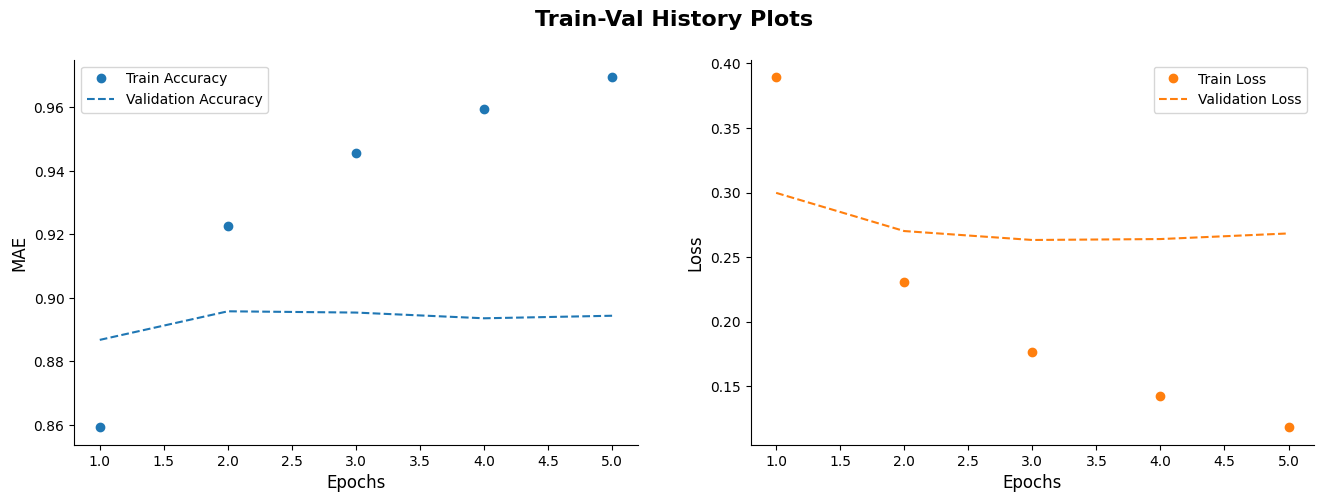

In [28]:
plot_history(history);

In [29]:
bow_model = keras.models.load_model("models/bow_model.keras")
bow_acc = bow_model.evaluate(bag_of_words_test_ds)[1]
bow_acc

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8883 - loss: 0.2812


0.8883200287818909

### Bi-Gram Model

#### Text Vectorization

In [30]:
max_tokens = 30_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,
)

In [31]:
text_vectorization.adapt(train_ds_no_labels)

In [32]:
bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [33]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(8, 30000)

In [34]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('first'),
 np.str_('most'),
 np.str_('him'),
 np.str_('it was'),
 np.str_('dont'),
 np.str_('one of'),
 np.str_('then'),
 np.str_('for the')]

#### Model Building

In [35]:
name = "bigram_classifier"

inputs = keras.Input(shape=(max_tokens,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
model = keras.Model(inputs, outputs, name=name)

In [36]:
model.summary()

Model: "bigram_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        30,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,001 (117.19 KB)

 Trainable params: 30,001 (117.19 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [38]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/bigram_model.keras", save_best_only=True
)

In [39]:
history = model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.8756 - loss: 0.3400 - val_accuracy: 0.9002 - val_loss: 0.2622
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9530 - loss: 0.1630 - val_accuracy: 0.8978 - val_loss: 0.2466
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9780 - loss: 0.1035 - val_accuracy: 0.8996 - val_loss: 0.2518
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9900 - loss: 0.0680 - val_accuracy: 0.8972 - val_loss: 0.2617


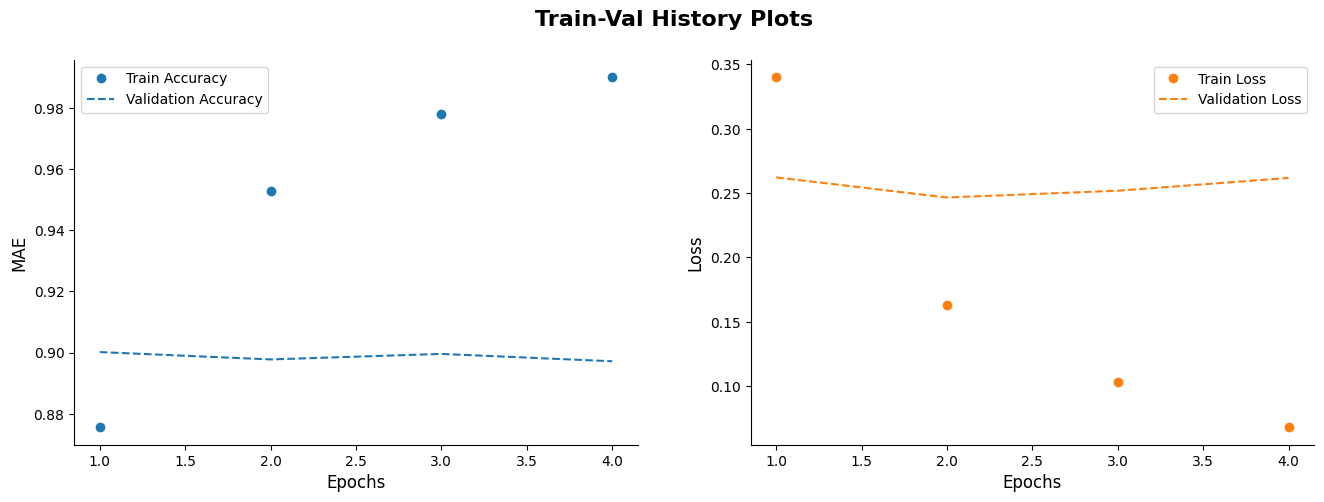

In [40]:
plot_history(history);

In [41]:
bigram_model = keras.models.load_model("models/bigram_model.keras")
bigram_acc = bigram_model.evaluate(bigram_test_ds)[1]
bigram_acc

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9020 - loss: 0.2504


0.9020400047302246

## 3 Sequence Models

### LSTM

#### Text Vectorization

In [11]:
max_length = 600
max_tokens = 30_000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(train_ds_no_labels)

In [12]:
sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [44]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(8, 600)

#### One-Hot Encoder

In [45]:
from keras import ops

class OneHotEncoding(keras.Layer):
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth

    def call(self, inputs):
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])
        one_hot_vectors = ops.eye(self.depth)
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)

In [46]:
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

torch.Size([8, 600, 30000])

#### Model Building

In [47]:
hidden_dim = 64

inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")

In [48]:
model.summary()

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot_encoding                │ (None, 600, 30000)     │             0 │
│ (OneHotEncoding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │    15,393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [50]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_model.keras", save_best_only=True
)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10


/home2/llorenzo/.conda/new_envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


 120/2500 ━━━━━━━━━━━━━━━━━━━━ 36:19 916ms/step - accuracy: 0.5122 - loss: 0.6928

45 minutes per iteration * 10 = 7.5 hours

In [56]:
lstm_model = keras.models.load_model(
    "models/lstm_model.keras",
    custom_objects={'OneHotEncoding': OneHotEncoding}
)
lstm_acc = lstm_model.evaluate(sequence_test_ds)[1]
lstm_acc

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1418s 454ms/step - accuracy: 0.8322 - loss: 0.4006


0.8321999907493591

### LSTM with Word Embedding

In [58]:
hidden_dim = 64

inputs = keras.Input(shape=(max_length,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_embedding")

In [59]:
model.summary()

Model: "lstm_with_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 600)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 600, 64)   │  1,920,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 600)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,986,177 (7.58 MB)

 Trainable params: 1,986,177 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [61]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_embedding.keras", save_best_only=True
)

In [62]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7608s 3s/step - accuracy: 0.7624 - loss: 0.4731 - val_accuracy: 0.8562 - val_loss: 0.3608
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7592s 3s/step - accuracy: 0.8709 - loss: 0.3013 - val_accuracy: 0.7770 - val_loss: 0.4834
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7604s 3s/step - accuracy: 0.8969 - loss: 0.2629 - val_accuracy: 0.8696 - val_loss: 0.3262
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7595s 3s/step - accuracy: 0.9582 - loss: 0.1188 - val_accuracy: 0.8718 - val_loss: 0.3648
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7575s 3s/step - accuracy: 0.9716 - loss: 0.0877 - val_accuracy: 0.8478 - val_loss: 0.5448


2 hours * 10 = 20 hours

In [65]:
lstm_with_embedding_model = keras.models.load_model("models/lstm_embedding.keras")
lstm_with_embedding_acc = lstm_with_embedding_model.evaluate(sequence_test_ds)[1]
lstm_with_embedding_acc

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5675s 2s/step - accuracy: 0.8618 - loss: 0.3583


0.8617600202560425

### Pretraining Word Embedding

In [15]:
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

#### Creating CBOW Dataset

In [16]:
import tensorflow as tf

context_size = 4
window_size = 9

def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)

    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[4]

    return bag, label

dataset = keras.utils.text_dataset_from_directory(
    data_dir / "train", batch_size=None
)
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
dataset = dataset.map(split_label, num_parallel_calls=8)

Found 75000 files belonging to 3 classes.


#### CBOW Model Training

In [17]:
hidden_dim = 64

inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(max_tokens, activation="sigmoid")(x)
cbow_model = keras.Model(inputs, outputs)

In [15]:
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [16]:
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/cbow_model.keras", save_best_only=True
)

In [ ]:
dataset = dataset.batch(256).cache()
cbow_model.fit(dataset, epochs=4, callbacks=[model_checkpoint])

Epoch 1/4
  66011/Unknown 5245s 79ms/step - loss: 6.6433 - sparse_categorical_accuracy: 0.0541

/home2/llorenzo/.conda/new_envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/home2/llorenzo/.conda/new_envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/callbacks/model_checkpoint.py:329: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


66012/66012 ━━━━━━━━━━━━━━━━━━━━ 5245s 79ms/step - loss: 6.2452 - sparse_categorical_accuracy: 0.0853
Epoch 2/4
  520/66012 ━━━━━━━━━━━━━━━━━━━━ 1:19:55 73ms/step - loss: 5.8790 - sparse_categorical_accuracy: 0.1222

25 seconds (1,000 iteration) * 75 * 4 = 2 hours

#### Loading Pretrained Embedding for Classification

In [18]:
inputs = keras.Input(shape=(max_length,))
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [19]:
cbow_model = keras.models.load_model("models/cbow_model.keras")
cbow_embedding = cbow_model.layers[1]

In [20]:
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

Parameter containing:
tensor([[-0.0355, -0.0101, -0.0012,  ...,  0.0174, -0.0434, -0.0324],
        [-0.2667, -0.0619,  0.2309,  ..., -0.0171,  0.0399, -0.3056],
        [-0.0768, -0.9006,  0.0646,  ..., -0.1054,  0.5779, -0.3147],
        ...,
        [-0.1246,  0.0095,  0.2509,  ...,  0.0526,  0.3024,  0.0174],
        [-0.0789, -0.1461, -0.1227,  ..., -0.1319,  0.2202,  0.0124],
        [ 0.4125,  0.1030, -0.2573,  ...,  0.0573,  0.2789,  0.3350]],
       requires_grad=True)

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [24]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "models/lstm_pretrained_embedding.keras", save_best_only=True
)

In [25]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint],
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11747s 5s/step - accuracy: 0.8062 - loss: 0.4317 - val_accuracy: 0.8372 - val_loss: 0.3607
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11469s 5s/step - accuracy: 0.8704 - loss: 0.3118 - val_accuracy: 0.8758 - val_loss: 0.2950
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11945s 5s/step - accuracy: 0.9030 - loss: 0.2471 - val_accuracy: 0.8930 - val_loss: 0.2806
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10730s 4s/step - accuracy: 0.9286 - loss: 0.1830 - val_accuracy: 0.8814 - val_loss: 0.2966
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10283s 4s/step - accuracy: 0.9483 - loss: 0.1412 - val_accuracy: 0.8848 - val_loss: 0.3150


2 hours * 10 = 20 hours

In [22]:
lstm_with_pretrained_embedding = keras.models.load_model(
    "models/lstm_pretrained_embedding.keras")
lstm_pretrained_embedding_acc = lstm_with_pretrained_embedding.evaluate(sequence_test_ds)[1]
lstm_pretrained_embedding_acc

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8775s 3s/step - accuracy: 0.8843 - loss: 0.3031


0.8843200206756592